# KernelGap Synthetic Dataset

In [1]:
# ── 0. Imports ─────────────────────────────────────────────────────────────────
from config.config import *
from config.experiments import ExperimentConfig

import src.data.saving as saving
import src.utils.visuals as visuals

from src.data.preprocessing import preprocess_synthetic
from src.data.synthetic import KernelGap_synthetic_dataset
from src.data.saving import candidate_exists, svm_exists, load_parameter_train, load_svm_results
from src.data.subsets import subset_random, subset_nystrom_global, subset_nystrom_stratified
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.pipeline import get_candidate, get_svm_results
from src.optimization.classical_base import classical_baseline
from src.utils.visuals import *

In [2]:
# ── 1. Data Import ────────────────────────────────────────────────────────────
# Labels come from the leading eigenvector of a fixed, entangling quantum
# kernel (reps=2 -> classically harder to simulate). A classical RBF kernel
# has a very different eigenstructure, so it should struggle where the
# quantum kernel (built from the very same feature map) will not.
X, y = KernelGap_synthetic_dataset(seed=45)
X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)

print(f"Dataset  : KernelGap Synthetic, 20 per class")
print(f"Train    : {X_train.shape}  |  Test: {X_test.shape}")

RESULTS_DIR = 'Results/KernelGap Synthetic'
saving.RESULTS_DIR = RESULTS_DIR
visuals.RESULTS_DIR = RESULTS_DIR

Dataset  : KernelGap Synthetic, 20 per class
Train    : (28, 4)  |  Test: (12, 4)


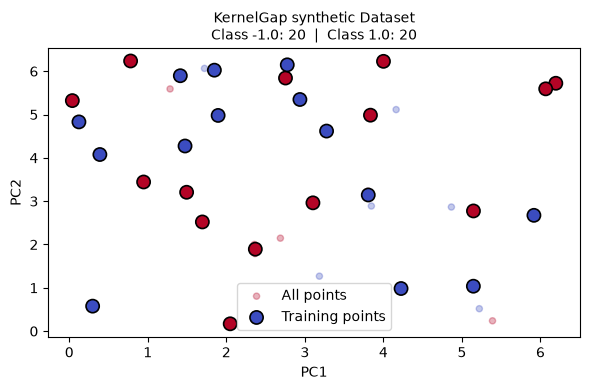

In [3]:
# ── 2. Dataset structure ─────────────────────────────────────────────────────────
graph_dataset('KernelGap synthetic', X, y, X_train, y_train, 'yes')

In [4]:
# ── 3. Experiments ─────────────────────────────────────────────────────────────
# This is the main section to edit. Each ExperimentConfig defines one run.
# Comment out any you don't want to include.
#
# name             → used as the Results subfolder name; must be unique
# optimizer        → 'optuna' or 'mealpy'
# variant          → 'geometric' or 'haar'
# subset_method    → 'random', 'nystrom_global', or 'nystrom_stratified'
# subset_kwargs    → passed to the chosen subset function
# optimizer_kwargs → passed to the chosen optimizer
# load_from        → (optional) load candidate from a different experiment name

EXPERIMENTS: list[ExperimentConfig] = [
    # Dataset is small (40 points) -> no subsetting needed, train on all of it.
    ExperimentConfig(
        name             = 'optuna 2',
        optimizer        = 'optuna',
        variant          = 'geometric',
        subset_method    = 'none',
        subset_kwargs    = {},
        optimizer_kwargs = {'n_trials': N_TRIALS},
    ),
    ExperimentConfig(
        name             = 'mealpy 2',
        optimizer        = 'mealpy',
        variant          = 'geometric',
        subset_method    = 'none',
        subset_kwargs    = {},
        optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
    ),
]

In [5]:
# ── 4. Run ─────────────────────────────────────────────────────────────────
# Cached results are reused automatically; delete Results/{name}/svm.pkl or
# Results/{name}/candidate.pkl to force a fresh run for that experiment.

summary = {}   # name → {accuracy, cv_acc, g_best, best_C}

# ── Classical baseline ──────────────────────────────────────────────────────
BASELINE = 'Classical_baseline 2'
if svm_exists(BASELINE):
    print(f"\nLoaded results of SVM for '{BASELINE}'")
    baseline_res = load_svm_results(BASELINE)
else:
    baseline_res = classical_baseline(X_train, y_train, X_test, y_test, name=BASELINE)

summary[BASELINE] = {
    'accuracy': baseline_res['accuracy'],
    'cv_acc':   float(baseline_res['best_cv_accuracy']),
    'best_C':   baseline_res['best_C'],
    'g_best':   float('nan'),
}

# ── Quantum experiments ─────────────────────────────────────────────────────
for config in EXPERIMENTS:
    print(f"\n{'─' * 60}")
    print(f" {config.name}  [{config.optimizer} + {config.subset_method}]")
    print(f"{'─' * 60}")

    # Step 1: Candidate (train or load from cache)
    candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
    g_best = load_parameter_train(config.load_from or config.name).get('g_best', float('nan'))

    # Step 2: SVM (run or load from cache)
    K_test = None
    if not svm_exists(config.name):
        print("Computing cross-kernel (test × subset)…")
        K_test = quantum_kernel_matrix_cross(X_test, X_sub, candidate)

    results = get_svm_results(config, K_train, y_sub, K_test, y_test)

    summary[config.name] = {
        'accuracy': results['accuracy'],
        'cv_acc':   float(results['best_cv_accuracy']),
        'best_C':   results['best_C'],
        'g_best':   g_best,
    }

2026/08/21 10:48:46 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: BaseGA(epoch=30, pop_size=20, pc=0.95, pm=0.1)



Loaded results of SVM for 'Classical_baseline 2'

────────────────────────────────────────────────────────────
 optuna 2  [optuna + none]
────────────────────────────────────────────────────────────
Loading cached candidate for 'optuna 2'
Loading cached SVM results for 'optuna 2'

────────────────────────────────────────────────────────────
 mealpy 2  [mealpy + none]
────────────────────────────────────────────────────────────


2026/08/21 10:51:50 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: 11.92823138815454, Global best: 13.455688667956839, Runtime: 81.70614 seconds
2026/08/21 10:52:51 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: 12.926032493017, Global best: 13.455688667956839, Runtime: 60.36003 seconds
2026/08/21 10:53:51 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: 12.92603249301732, Global best: 13.455688667956839, Runtime: 60.41771 seconds
2026/08/21 10:54:45 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: 11.715339176017848, Global best: 13.455688667956839, Runtime: 54.11242 seconds
2026/08/21 10:55:41 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: 12.544791493614479, Global best: 13.455688667956839, Runtime: 56.26016 seconds
2026/08/21 10:56:41 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P

Saved candidate  → Results/KernelGap Synthetic/mealpy 2/candidate.pkl
Loading cached SVM results for 'mealpy 2'


In [6]:
# ── 5. Summary table ───────────────────────────────────────────────────────

def print_summary(summary: dict) -> None:
    W = 32
    print(f"\n{'═' * 75}")
    print(f"  {'EXPERIMENT':<{W}} {'TEST ACC':>9} {'CV ACC':>9} {'g_best':>9} {'best C':>6}")
    print(f"{'─' * 75}")
    for name, s in summary.items():
        g = f"{s['g_best']:9.2f}" if not np.isnan(s['g_best']) else f"{'—':>9}"
        print(f"  {name:<{W}} {s['accuracy']:>9.4f} {s['cv_acc']:>9.4f} {g} {s['best_C']:>6}")
    print(f"{'═' * 75}\n")

print_summary(summary)


═══════════════════════════════════════════════════════════════════════════
  EXPERIMENT                        TEST ACC    CV ACC    g_best best C
───────────────────────────────────────────────────────────────────────────
  Classical_baseline 2                0.7500    0.8500         —     10
  optuna 2                            0.5833    0.3167     14.62   1000
  mealpy 2                            0.3333    0.5167     13.46    0.1
═══════════════════════════════════════════════════════════════════════════



In [7]:
# ── 6. Visualizations ──────────────────────────────────────────────────────
plot_accuracy(summary, ['test'])
plot_g_best(summary)
plot_kernel_heatmaps(summary)

KeyError: 'Classical_baseline'